### Analysis of learned plasticity rule that organizes integrating network
Networks initialized with structured input weights, but weights in 'ellipsoid body' are random but fully connected.

In [62]:
%load_ext autoreload
%autoreload 2

import numpy as np
import glob as glob
import matplotlib
import matplotlib.pyplot as plt
import os
from aux import zero_pad, format_plot, format_pc_plot, add_inset_axes
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn import linear_model
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.offline as pyo
import subprocess
import cv2
from natsort import natsorted
import seaborn as sns

plt.rcParams['font.family'] = 'Helvetica'

DATA_PATHS = [
    'hardcoded_instant_inh_hard_coded_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8015_2025-08-20_11:33:11.529326_run_None',
    'hardcoded_instant_inh_inh_het_0p1_hard_coded_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8015_2025-08-20_11:48:40.649392_run_None',
    'hardcoded_instant_inh_inh_het_0p2_hard_coded_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8015_2025-08-20_11:54:17.920393_run_None',
    'hardcoded_instant_inh_inh_het_0p3_hard_coded_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8015_2025-08-20_11:41:14.470460_run_None',
]

DATA_PATHS = [ './sims_out/' + d for d in DATA_PATHS]

CELL_TYPE_1_SIZE = 15

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
def load_numpy(data_path):
    file_names = glob.glob(data_path)
    data = []
    for file_name in sorted(file_names):
        data_for_file = np.load(file_name)
        data.append(data_for_file)
    return data

def make_path_if_not_exists(path_str):
    Path(path_str).mkdir(parents=True, exist_ok=True)

### Analysis of neural activity

In [3]:
def load_r_and_int_values(rule_path, net_path, last_n=100, trim_from_r=200):
    all_r = np.stack(load_numpy(os.path.join(rule_path, 'activities', net_path)))
    all_int_values = np.stack(load_numpy(os.path.join(rule_path, 'integrated_values', net_path)))
    
    if last_n is not None:
        last_n_r = all_r[-last_n:, trim_from_r:, :15]
        all_int_values = all_int_values[-last_n:, :]
    else:
        last_n_r = all_r[:, trim_from_r:, :15]
        
    last_n_r = np.transpose(last_n_r, [2, 0, 1])

    return last_n_r, all_int_values

In [4]:
def load_inputs(rule_path, net_path):
    all_inputs = np.stack(load_numpy(os.path.join(rule_path, 'inputs', net_path)))
    return all_inputs

Do PCA on last 50 trials, 15 units in ellipsoid body.

In [5]:
def fit_pca(last_100_r):
    flattened_data = last_100_r.reshape(last_100_r.shape[0], last_100_r.shape[1] * last_100_r.shape[2], order='C')
    pca = PCA()
    pc_activities = pca.fit_transform(flattened_data.T)
    pc_activities = pc_activities.T.reshape(last_100_r.shape, order='C')

    return pc_activities, pca

Learned structure leads to low dimensional activity.

In [6]:
def make_tuning_curves(last_100_r, all_int_values):
    scale = 4
    
    inputs_raw = load_numpy(os.path.join(DATA_PATHS[0], 'inputs/net_001_*.npy'))
    inputs = np.concatenate([np.zeros((100, 200, 30)), np.stack(inputs_raw[-100:])], axis=1)
    
    ending_states = np.empty((last_100_r.shape[0], last_100_r.shape[1]))
    
    for i, j in enumerate(np.argsort(all_int_values[:, -1])):
        
        if i % 20 == 0 or i == len(all_int_values[:, -1]) - 1:
            fig, axs = plt.subplots(2, 1, figsize=(1 * scale, 1 * scale))
            axs[0].matshow(inputs[j, :, :15].T, cmap='binary', vmin=0, vmax=5, aspect=10)
            axs[1].matshow(inputs[j, :, 15:].T, cmap='binary', vmin=0, vmax=5, aspect=10)
            for k in range(2):
                axs[k].set_xlabel('Time (ms)', fontsize=16)
                axs[k].set_ylabel('Neuron', fontsize=16)
                axs[k].set_xticks(np.arange(0, 1001, 200), (np.arange(0, 1001, 200) / 10).astype(int))
                axs[k].set_yticks([0, 15])
                axs[k].tick_params(axis='x', bottom=True, top=False, labelbottom=True, labeltop=False)
                axs[k].xaxis.set_label_position('bottom')
                axs[k].tick_params(axis='both', length=6, labelsize=16)
    
            fig, axs = plt.subplots(1, 1, figsize=(1 * scale, 1 * scale))
            axs.matshow(last_100_r[:, j, :], cmap='bwr', vmin=-2, vmax=2, aspect=100)
            axs.set_xlabel('Time (ms)', fontsize=16)
            axs.set_ylabel('Neuron', fontsize=16)
            axs.set_xticks(np.arange(0, 5001, 1000), (np.arange(0, 5001, 1000) / 10).astype(int))
            axs.set_yticks([0, 15])
            axs.tick_params(axis='x', bottom=True, top=False, labelbottom=True, labeltop=False)
            axs.xaxis.set_label_position('bottom')
            axs.tick_params(axis='both', length=6, labelsize=16)
        
    for i, j in enumerate(np.argsort(all_int_values[:, -250])):
        ending_states[:, i] = last_100_r[:, j, -250]
        
    #     fig.savefig(os.path.join(img_path, f'act_{zero_pad(run, 4)}_t_{zero_pad(timestep, 4)}.png'))
    #     plt.close()
    
    scale = 3.5
    fig, axs = plt.subplots(1, 1, figsize=(1 * scale, 1 * scale))
    axs.matshow(ending_states, cmap='bwr', vmin=-2, vmax=2, aspect=4)
    
    format_plot(axs, rightspine=True, topspine=True)
    
    axs.set_xlabel('Integrated sum', fontsize=16)
    axs.set_xticks([0, 100], ['Leftmost', 'Rightmost'])
    axs.set_ylabel('Neuron', fontsize=16)
    axs.set_yticks([0, 14])
    axs.tick_params(axis='both', length=6, labelsize=16)
    
    scale = 2
    fig, axs = plt.subplots(1, 1, figsize=(1.8 * scale, 1 * scale))
    
    import matplotlib.pyplot as plt
    import numpy as np
    
    plasma = plt.get_cmap("plasma")
    colors = [plasma(i / 100)[:3] for i in range(100)]  # 49 to include 0 and 1
    
    for i in range(ending_states.shape[1]):
        axs.plot(np.arange(ending_states.shape[0]), ending_states[:, i], color=colors[i], lw=1)
    
    format_plot(axs)
    
    axs.set_ylabel('Firing rate (Hz)', fontsize=16)
    axs.set_xlabel('Neuron', fontsize=16)
    axs.set_xticks([0, 14])
    axs.set_xlim(0, 14)
    axs.tick_params(axis='both', length=6, labelsize=16)
    

In [7]:
def make_tuning_curves(last_100_r, all_int_values, save_name_1=None, save_name_2=None):
    ending_states = np.empty((last_100_r.shape[0], last_100_r.shape[1]))
    int_values_for_ending_states = np.empty((all_int_values.shape[0]))
    for i, j in enumerate(np.argsort(all_int_values[:, -250])):
        ending_states[:, i] = last_100_r[:, j, -250]
        int_values_for_ending_states[i] = all_int_values[j, -250]
    
    scale = 2
    fig, axs = plt.subplots(1, 1, figsize=(1 * scale, 1 * scale))
    m = np.abs(ending_states).max()
    axs.matshow(ending_states, cmap='bwr', vmin=-m, vmax=m, aspect=4)
    
    format_plot(axs, rightspine=True, topspine=True)
    
    axs.set_xlabel('Integrated sum', fontsize=16)
    axs.set_xticks([0, 100], ['Leftmost', 'Rightmost'])
    axs.set_ylabel('Neuron', fontsize=16)
    axs.set_yticks([0, 14])
    axs.tick_params(axis='both', length=6, labelsize=16)

    if save_name_1 is not None:
        fig.savefig(save_name_1, bbox_inches='tight')
    
    scale = 2
    fig, axs = plt.subplots(1, 1, figsize=(1.5 * scale, 1 * scale))
    
    cmap = sns.diverging_palette(145, 300, s=60, as_cmap=True)
    int_min, int_max = int_values_for_ending_states.min(), int_values_for_ending_states.max()
    colors = [cmap((int_values_for_ending_states[i] - int_min) / (int_max - int_min))[:3] for i in range(100)]  # 49 to include 0 and 1
    
    for i in range(ending_states.shape[1]):
        axs.plot(np.arange(ending_states.shape[0]), ending_states[:, i], color=colors[i], lw=1)

    norm = matplotlib.colors.Normalize(vmin=int_min, vmax=int_max)
    sm = matplotlib.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])  # Only needed for older versions of matplotlib
    cbar = fig.colorbar(sm, ax=axs, orientation='vertical', pad=0.02)
    cbar.set_label("Integrated value")
    format_plot(cbar.ax)
    
    format_plot(axs)
    
    axs.set_ylabel('Firing rate (Hz)', fontsize=16)
    axs.set_xlabel('Neuron', fontsize=16)
    axs.set_xticks([0, 14])
    axs.set_xlim(0, 14)
    axs.tick_params(axis='both', length=6, labelsize=16)

    if save_name_2 is not None:
        fig.savefig(save_name_2, bbox_inches='tight')

In [55]:
def make_stability_plot(last_100_r, all_int_values, save_name=None, plot_stride=1, alpha=0.5, tick_stride=1000):
    from matplotlib.collections import LineCollection
    
    cmap = sns.diverging_palette(145, 300, s=60, as_cmap=True)
    scale = 3
    time_diff = last_100_r.shape[-1] - all_int_values.shape[-1]
    if time_diff > 0:
        all_int_values = np.concatenate([
            all_int_values,
            all_int_values[:,-1:] * np.ones((all_int_values.shape[0], time_diff)),
        ], axis=1)
    
    def normed_loc(raster):
        raster_mean_normed = raster
        total_activity = raster_mean_normed.sum(axis=0)
        raster_normed = np.divide(
            raster_mean_normed,
            total_activity[None, ...],
            where=total_activity != 0,
            out=np.zeros_like(raster_mean_normed)
        )
        ordered_indices = np.argsort(raster_normed, axis=0)
        max_5_indices = ordered_indices[-13:, :]
        x = np.arange(raster_mean_normed.shape[0])
        cols = np.arange(raster.shape[1])[None, :]
        locs = np.einsum(
            'ij,ij->j',
            x[max_5_indices],
            raster_normed[max_5_indices, cols],
        )
        return locs
    all_final_traj = []
    # Create a figure with 2 columns: main plot and histogram
    fig = plt.figure(figsize=(1.3 * scale, 0.7 * scale))
    gs = gridspec.GridSpec(1, 2, width_ratios=[5, 1], wspace=0.05)
    ax_main = fig.add_subplot(gs[0])
    ax_hist = fig.add_subplot(gs[1], sharey=ax_main)
    sorted_int_values = []
    # Use global color normalization for consistent coloring
    global_max = np.max(np.abs(all_int_values))
    norm = matplotlib.colors.Normalize(vmin=-global_max, vmax=global_max)
    all_traj = []

    normed_last_100_r = last_100_r / last_100_r[..., -1000:].max(axis=(1, 2)).reshape((last_100_r.shape[0], 1, 1))
    
    for i, j in enumerate(np.argsort(all_int_values[:, -1])):
        traj = normed_loc(normed_last_100_r[:, j, :])
        all_final_traj.append(traj[-1])
        
        # Create line segments for coloring
        x = np.arange(all_int_values.shape[1])
        traj_plot = traj[::plot_stride]
        x_plot = x[::plot_stride]
        points = np.array([x_plot, traj_plot]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)
        
        # Color by the value at each point (use midpoint or start of segment)
        colors = all_int_values[j, :][::plot_stride]
        
        # Create LineCollection with varying colors
        lc = LineCollection(segments, cmap=cmap, norm=norm, alpha=alpha, lw=0.5)
        lc.set_array(colors[:-1])  # Use color at start of each segment
        lc.set_linewidth(1.5)
        lc.set_rasterized(True)
        ax_main.add_collection(lc)
        
        sorted_int_values.append(all_int_values[j, :])
        all_traj.append(traj)
    all_traj = np.stack(all_traj)

    # Main plot formatting
    ax_main.set_xlabel('Time (ms)')
    ax_main.set_ylabel('Bump location')
    ax_main.set_xticks(np.arange(0, last_100_r.shape[-1], tick_stride))
    ax_main.set_xticklabels((np.arange(0, last_100_r.shape[-1], tick_stride) / 10).astype(int))
    center_point = 0.5 * CELL_TYPE_1_SIZE
    m = np.maximum(center_point - all_traj.min(), all_traj.max() - center_point)
    ax_main.set_ylim(center_point - m * 1.1, center_point + m * 1.1)
    ax_main.set_yticks([0, CELL_TYPE_1_SIZE - 1], [1, CELL_TYPE_1_SIZE])
    ax_main.set_xlim(0, last_100_r.shape[-1])
    # ax_main.tick_params(axis='both', length=6, labelsize=14)
    format_plot(ax_main) #, ticklabelsize=16, axislabelsize=16)

    # Histogram on the right (rotated)
    bins = np.arange(30) / 30 * (CELL_TYPE_1_SIZE - 1)

    # First histogram
    counts1, _ = np.histogram(all_final_traj, bins=bins)
    ax_hist.stairs(
        counts1,
        bins,
        orientation="horizontal",
        color="blue",
        linewidth=1,
    )
    
    # Second histogram
    vals2 = (all_int_values[:, -1] - np.mean(all_int_values[:, -1])) / 10 + center_point
    counts2, _ = np.histogram(vals2, bins=bins)
    ax_hist.stairs(
        counts2,
        bins,
        orientation="horizontal",
        color="gray",
        linewidth=1,
    )
    
    ax_hist.set_xlabel("Count")
    ax_hist.tick_params(axis="x")
    ax_hist.tick_params(axis="y", labelleft=False)
    format_plot(ax_hist)

    if save_name is not None:
        fig.savefig(save_name + '_stability_plot.svg', bbox_inches='tight')

    plt.show()

    fig, axs = plt.subplots(1, 1, figsize=(0.5 * scale, 0.5 * scale))

    # axs.plot([-m, m], [-m, m], color='black', zorder=0)
    axs.scatter(np.stack(sorted_int_values)[:, -1], all_final_traj, s=3, zorder=1, facecolor='red', edgecolor='red', alpha=0.5)
    # axs.set_xlim(-m, m)
    # axs.set_ylim(-m, m)
    # axs.set_xticks([-100, 0, 100])
    # axs.set_yticks([-100, 0, 100])
    # axs.set_ylim(-0.05, 1.05)
    format_plot(axs)

    axs.set_xlabel(r'$\int \left( I_{\rm R} - I_{\rm L} \right)$') #, fontsize=16)
    axs.set_ylabel('Bump location') # , fontsize=16)
    # axs.set_title('Predicted vs true integrated sums', fontsize=16)
    # axs.tick_params(axis='both', length=6,)

    if save_name is not None:
        fig.savefig(save_name + '_bump_vs_value.svg', bbox_inches='tight')

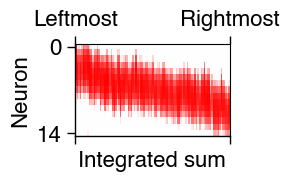

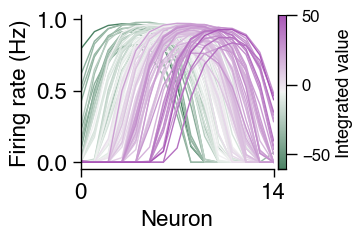

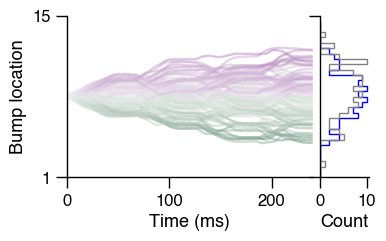

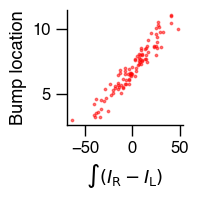

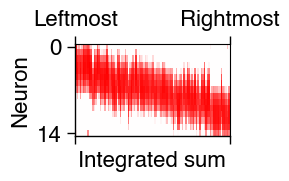

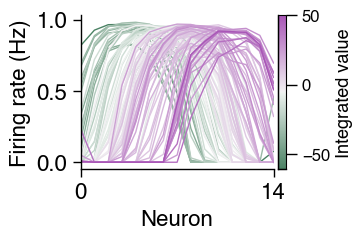

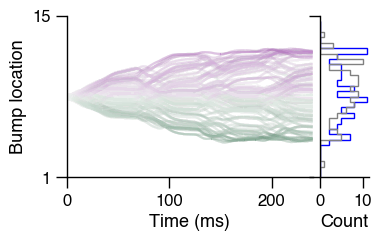

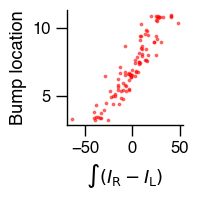

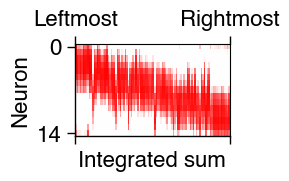

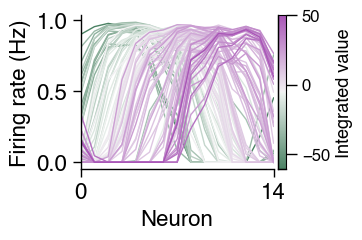

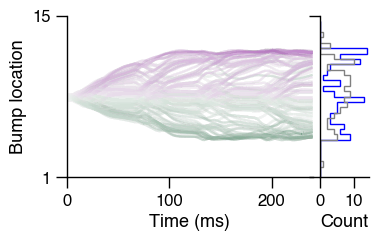

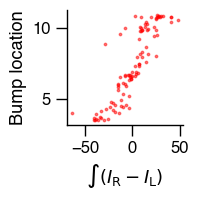

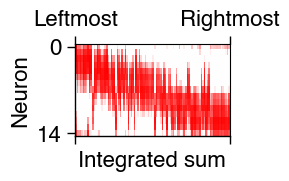

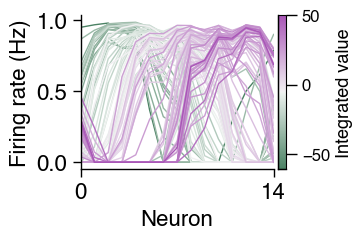

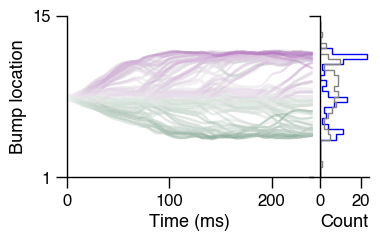

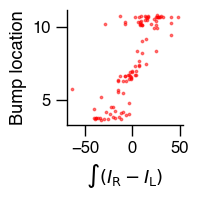

In [56]:
for i_d, dp in enumerate(DATA_PATHS):
    for i in range(8, 9):
        last_100_r, all_int_values = load_r_and_int_values(dp, f'net_00{i}_*.npy')
        make_tuning_curves(last_100_r, all_int_values, save_name_2=f'./figures/hard_coded_tuning_curve_inh_het_{i_d}.svg')
        make_stability_plot(last_100_r, all_int_values, save_name=f'./figures/hard_coded_stability_plot_inh_het_{i_d}.svg')

In [103]:
from matplotlib.colors import TwoSlopeNorm

def plot_step(all_w, run, v=2, lims=None, save_name=None):
    scale = 1.5
    fig, axs = plt.subplots(1, 1, figsize=(1 * scale, 1 * scale))
    
    cmap = sns.diverging_palette(250, 10, s=100, l=55, as_cmap=True)

    # Use TwoSlopeNorm to ensure white maps to 0
    norm = TwoSlopeNorm(vmin=-v, vcenter=0, vmax=v)
    
    # Plot the matrix
    w = all_w[run] if lims is None else all_w[run][lims[0]:lims[1]+1, lims[0]:lims[1]+1]
    im = axs.matshow(w, cmap=cmap, norm=norm)

    # Ticks and labels
    if lims is None:
        axs.set_xticks([15, 30, 45])
        axs.set_yticks([15, 30, 45])
    else:
        axs.set_xticks(lims, np.array(lims)+1)
        axs.set_yticks(lims, np.array(lims)+1)
    axs.set_xlabel('Presynaptic')
    axs.set_ylabel('Postsynaptic')
    axs.xaxis.set_label_position('top')
    axs.tick_params(axis='x', bottom=False)
    axs.tick_params(axis='both', length=10)
    axs.spines['right'].set_visible(False)
    axs.spines['bottom'].set_visible(False)

    # Add colorbar
    cbar = fig.colorbar(im, ax=axs, fraction=0.046, pad=0.04)
    cbar.set_label('Weight')

    format_plot(axs, topspine=True, rightspine=True)
    format_plot(cbar.ax)

    if save_name is not None:
        fig.savefig(save_name, bbox_inches='tight')

    return fig

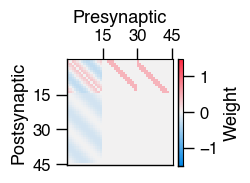

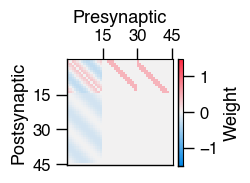

In [104]:
w = load_numpy(os.path.join(DATA_PATHS[0], 'weights/net_008_*.npy'))
plot_step(w, 0, v=1.5, save_name='figures/hardcoded_int_connectivity.svg')

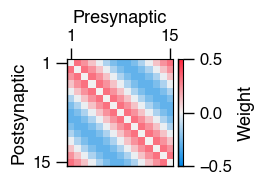

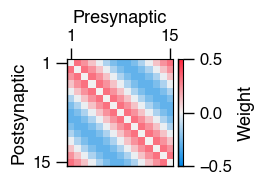

In [115]:
w = load_numpy(os.path.join(DATA_PATHS[0], 'weights/net_008_*.npy'))
plot_step(w, 0, v=0.5, save_name='figures/hardcoded_int_connectivity_ee.svg', lims=(0,14))

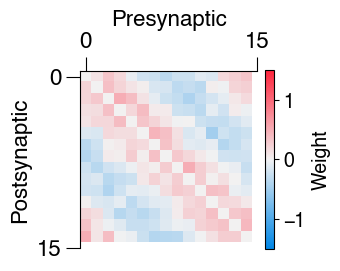

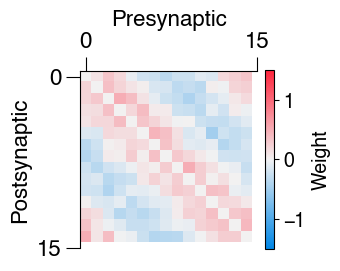

In [21]:
w = load_numpy(os.path.join(DATA_PATHS[3], 'weights/net_008_*.npy'))
plot_step(w, 0, v=1.5, save_name='figures/hardcoded_int_connectivity_disrupted.svg', lims=(0,15))

In [108]:
def plot_raw_trajectory(inputs_raw, last_100_r, all_int_values):
    scale = 2.5
    inputs = np.concatenate([np.zeros((100, 200, 30)), inputs_raw[-100:, ...]], axis=1)
    ending_states = np.empty((last_100_r.shape[0], last_100_r.shape[1]))
    
    for i, j in enumerate(np.argsort(all_int_values[:, -1])):
        
        if i % 20 == 0 or i == len(all_int_values[:, -1]) - 1:
            fig, axs = plt.subplots(2, 1, figsize=(1.3 * scale, 1 * scale), sharex=True)
            axs[0].matshow(inputs[j, :, :15].T, cmap='binary', vmin=0, vmax=30, aspect=30)
            axs[1].matshow(inputs[j, :, 15:].T, cmap='binary', vmin=0, vmax=30, aspect=30)
            for k in range(2):
                if k == 0:
                    axs[k].set_ylabel('Neuron')
                    axs[k].set_yticks([0, 15], [15, 30])
                else:
                    axs[k].set_ylabel('Neuron')
                    axs[k].set_yticks([0, 15], [30, 45])
                    axs[k].set_xlabel('Time (ms)')
                axs[k].set_xticks(np.arange(0, 2501, 2500), (np.arange(0, 2501, 2500) / 10).astype(int))
                axs[k].tick_params(axis='x', bottom=True, top=False, labelbottom=True, labeltop=False)
                axs[k].xaxis.set_label_position('bottom')
            format_plot(axs, topspine=True, rightspine=True)
    
                # axs[k].axvline(x=20 * 10, color='purple', linestyle='--', linewidth=2)
                # axs[k].axvline(x=105 * 10, color='purple', linestyle='--', linewidth=2)
            fig.savefig(f'./figures/hardcoded_inh_het_inputs_{i}.svg', bbox_inches='tight')
    
    
            fig, axs = plt.subplots(1, 1, figsize=(1.3 * scale, 1 * scale))
            axs.plot(np.arange(inputs.shape[1]), 7.5 - np.cumsum((inputs[j, :, :15] - inputs[j, :, 15:]).sum(axis=-1) / 25000), zorder=1, color='blue', linewidth=2)
            mappable = axs.matshow(last_100_r[:, j, :], cmap=sns.color_palette('Reds', as_cmap=True), vmin=0, vmax=1, aspect=30, zorder=0)
            cbar = fig.colorbar(mappable, fraction=0.04, aspect=4)
            axs.set_xlabel('Time (ms)')
            axs.set_ylabel('Neuron\nactivity')
            axs.set_xticks(np.arange(0, 2501, 2500), (np.arange(0, 2501, 2500) / 10).astype(int))
            axs.set_yticks([0, 14], [1, 15])
            axs.tick_params(axis='x', bottom=True, top=False, labelbottom=True, labeltop=False)
            axs.xaxis.set_label_position('bottom')
            axs.tick_params(axis='both')
            format_plot(cbar.ax)
            format_plot(axs, topspine=True, rightspine=True)
            # axs.axvline(x=20 * 10, color='purple', linestyle='--', linewidth=2)
            # axs.axvline(x=105 * 10, color='purple', linestyle='--', linewidth=2)
            fig.savefig(f'./figures/hardcoded_inh_het_single_pool_activity_trace_{i}.svg', bbox_inches='tight')
        
    for i, j in enumerate(np.argsort(all_int_values[:, -250])):
        ending_states[:, i] = last_100_r[:, j, -250]
        
    #     fig.savefig(os.path.join(img_path, f'act_{zero_pad(run, 4)}_t_{zero_pad(timestep, 4)}.png'))
    #     plt.close()

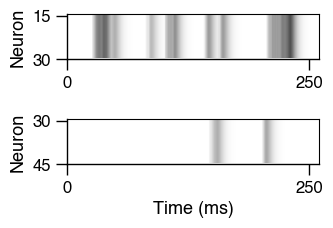

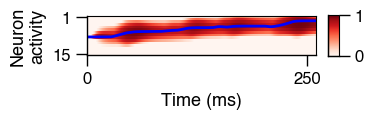

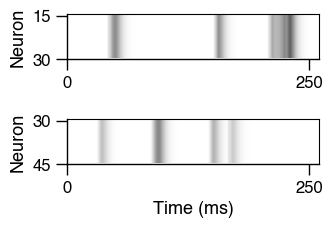

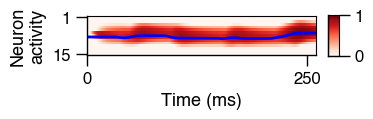

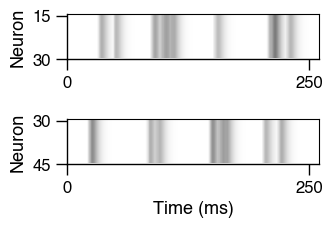

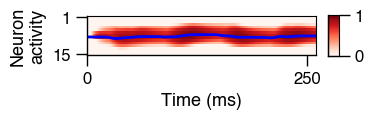

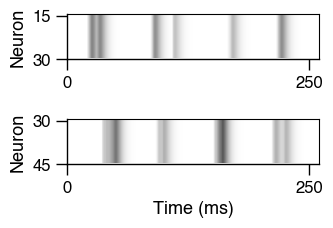

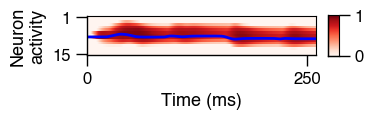

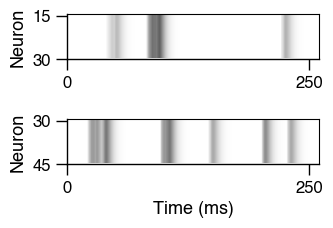

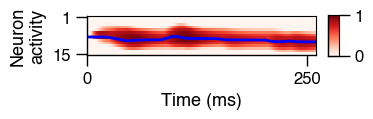

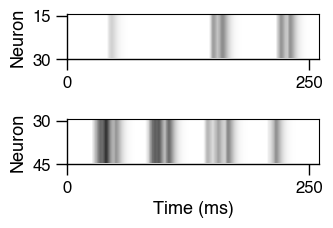

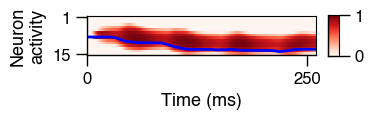

In [109]:
for i_d, dp in enumerate([DATA_PATHS[0]]):
    for i in range(8, 9):
        last_100_r, all_int_values = load_r_and_int_values(dp, f'net_00{i}_*.npy', trim_from_r=0)
        inputs = load_inputs(dp, f'net_00{i}_*.npy')
        plot_raw_trajectory(inputs, last_100_r, all_int_values)

In [18]:
from scipy.stats import gaussian_kde

def test_representation_fidelity(all_r, all_int_values, n_fold=20, lasso_alpha=0.1):

    train_range = slice(0, 40)
    test_range = slice(40, 140)
    
    stacked_activities_train = all_r[:, train_range, :]
    y_train = all_int_values[train_range, :]
    stacked_activities_test = all_r[:, test_range, :]
    y_test = all_int_values[test_range, :]
    
    scores = []
    
    for i in range(n_fold):
        train_acts = np.random.randint(0, 40, size=8000)
        train_steps = np.random.randint(0, 2250, size=8000)
        test_acts = np.arange(100)
        test_steps = np.random.randint(0, 2250, size=100)
        
        X_train = stacked_activities_train[:, train_acts, train_steps + 50].T # add 5 ms lag between inputs and decoded value
        Y_train = y_train[train_acts, train_steps]

        kde = gaussian_kde(Y_train)
        
        X_test = stacked_activities_test[:, test_acts, test_steps + 50].T # add 5 ms lag between inputs and decoded value
        Y_test = y_test[test_acts, test_steps]
        
        reg = linear_model.Lasso(alpha=lasso_alpha).fit(X_train, Y_train, sample_weight=1 / kde(Y_train))
        score = reg.score(X_test, Y_test)
        scores.append(score)
    
    print(scores)
    print(np.mean(scores))

    # scale = 0.8
    # fig, axs = plt.subplots(1, 1, figsize=(4 * scale, 4 * scale))

    # Y_hat = reg.predict(X_test)

    # m = 1.05 * np.max(np.abs(np.concatenate([Y_test, Y_hat])))
    
    # axs.plot([-m, m], [-m, m], color='black', zorder=0)
    # axs.scatter(Y_test, Y_hat, s=30, zorder=1, facecolor='none', edgecolor='red', alpha=0.5)
    # axs.set_xlim(-m, m)
    # axs.set_ylim(-m, m)
    # axs.set_xticks([-100, 0, 100])
    # axs.set_yticks([-100, 0, 100])
    
    # format_plot(axs)
    
    # axs.set_xlabel(r'$y$', fontsize=16)
    # axs.set_ylabel(r'$\hat{y}$', fontsize=16)
    # axs.set_title('Predicted vs true integrated sums', fontsize=16)
    # axs.tick_params(axis='both', length=6, labelsize=16)

    return np.mean(scores)

In [20]:
all_scores = []
for dp in DATA_PATHS:
    scores_for_dp = []
    for i in range(10):
        all_r, all_int_values = load_r_and_int_values(dp, f'net_00{i}_*.npy', last_n=None)
        score = test_representation_fidelity(all_r, all_int_values, n_fold=5)
        scores_for_dp.append(score)
    all_scores.append(scores_for_dp)

[0.8968665761087916, 0.8907937392208333, 0.8734310767620957, 0.8787889185981668, 0.8997555109790589]
0.8879271643337893
[0.9074337235331752, 0.8782232630280721, 0.8865078641880789, 0.8890244489426958, 0.8868583419390081]
0.889609528326206
[0.920605994818369, 0.8908850417352925, 0.8879872091766547, 0.8890661100562168, 0.8740998890698778]
0.8925288489712822
[0.9217409288464896, 0.9158595769835229, 0.9131032824300501, 0.9072631157577763, 0.8959948792843389]
0.9107923566604356
[0.9301111266917251, 0.9244293877041946, 0.9150917800588002, 0.9031836706729676, 0.9463634310343486]
0.9238358792324073
[0.8507684744048654, 0.8767207858503627, 0.8995578602086344, 0.8800086448154343, 0.8536824447615492]
0.8721476420081693
[0.887666398071733, 0.8544120020597248, 0.8980140950910719, 0.9103507868913546, 0.8975745875032703]
0.8896035739234309
[0.8647122571075196, 0.8936854524515314, 0.8641179924745812, 0.8687464928157413, 0.8752509505211067]
0.8733026290740961
[0.8846438996068325, 0.8952693990472954, 0.

In [22]:
all_scores_cp = np.array(all_scores)

In [88]:
np.save('preprocessing/hard_coded_r2_scores_inh_het.npy', all_scores_cp)

In [89]:
all_scores_cp = np.load('preprocessing/hard_coded_r2_scores_inh_het.npy')

Axes(0.125,0.11;0.775x0.77)


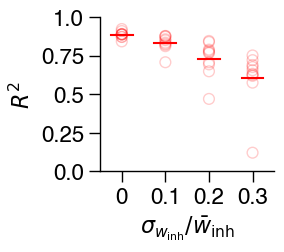

In [90]:
fig, axs = plt.subplots(1, 1, figsize=(2.25, 2))

offset = 0.5  # horizontal offset for boxplots
for k in range(all_scores_cp.shape[0]):
    x_scatter = np.ones(all_scores_cp.shape[1]) * k
    axs.scatter(x_scatter, all_scores_cp[k, :],
                facecolor='none', edgecolor='red', s=60, alpha=0.2)

    mean_line_width = 0.25
    axs.plot([k - mean_line_width, k + mean_line_width], np.mean(all_scores_cp[k, :]) * np.ones(2), c='red', lw=1.5)
    
    
    # Add boxplot shifted slightly to the right
    # axs.boxplot(all_scores_cp[k, :],
    #             positions=[k + offset],
    #             widths=0.25,
    #             patch_artist=True,
    #             boxprops=dict(facecolor='white', color='black'),
    #             medianprops=dict(color='black'),
    #             whiskerprops=dict(color='black'),
    #             capprops=dict(color='black'),
    #             flierprops=dict(marker='o', color='black', alpha=0.3))

axs.set_yticks(np.arange(5) * 0.25, np.arange(5) * 0.25)
axs.set_xticks(np.arange(4), ['0'] + [f'{v:.1f}' for v in np.arange(1, 4) * 0.1])
axs.set_ylim(0, 1)
axs.set_xlim(-0.5, 3.5)

axs.set_xlabel(r'$\sigma_{w_{\rm inh}} / \bar{w}_{\rm inh}$')
axs.set_ylabel(r'$R^2$')

format_plot(axs, ticklabelsize=16, axislabelsize=16)
fig.savefig('figures/hard_coded_accuracy_versus_inh_het.svg')
fig.savefig('figures/hard_coded_accuracy_versus_inh_het.png')


Axes(0.125,0.11;0.775x0.77)


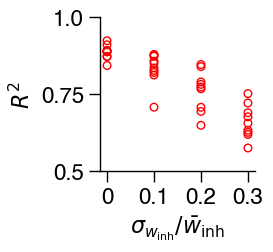

In [52]:
fig, axs = plt.subplots(1, 1, figsize=(2, 2))
for k in range(all_scores_cp.shape[0]):
    axs.scatter(np.ones(all_scores_cp.shape[1]) * k, all_scores_cp[k, :], facecolor='none', edgecolor='red', s=30)

axs.set_yticks(np.arange(5) * 0.25, np.arange(5) * 0.25)
axs.set_xticks(np.arange(4), ['0'] + [f'{v:.1f}' for v in np.arange(1, 4) * 0.1])
axs.set_ylim(0.5, 1)

axs.set_xlabel(r'$\sigma_{w_{\rm inh}} / \bar{w}_{\rm inh}$')
axs.set_ylabel(r'$R^2$')

format_plot(axs, ticklabelsize=16, axislabelsize=16)
